# Actividad: Clasificación con KNN, SVM y Árboles de Decisión — Dataset Iris

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, accuracy_score,
                              precision_score, recall_score, f1_score)

sns.set_style("whitegrid")
pd.set_option("display.precision", 4)

## 2. Carga y exploración de datos

cargar el `.csv` con `pandas` y revisar su estructura antes de modelar.

In [2]:
iris = pd.read_csv("Iris.csv")
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
# Estadísticas descriptivas de las variables numéricas
iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.0000,150.0000,150.0000,150.0000,150.0000
mean,75.5000,5.8433,3.0540,3.7587,1.1987
std,43.4454,0.8281,0.4336,1.7644,0.7632
min,1.0000,4.3000,2.0000,1.0000,0.1000
25%,38.2500,5.1000,2.8000,1.6000,0.3000
50%,75.5000,5.8000,3.0000,4.3500,1.3000
75%,112.7500,6.4000,3.3000,5.1000,1.8000
max,150.0000,7.9000,4.4000,6.9000,2.5000


In [5]:
# Verificar valores nulos
iris.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


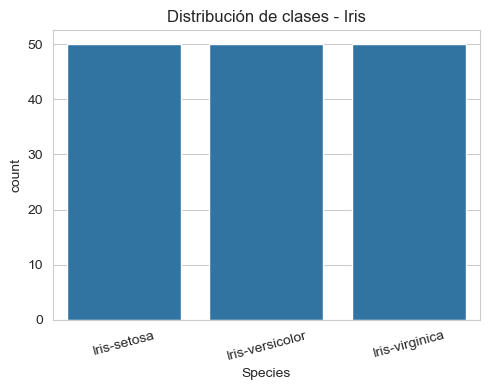

In [6]:
# Distribución de clases (variable objetivo)
print(iris["Species"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(data=iris, x="Species")
plt.title("Distribución de clases - Iris")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

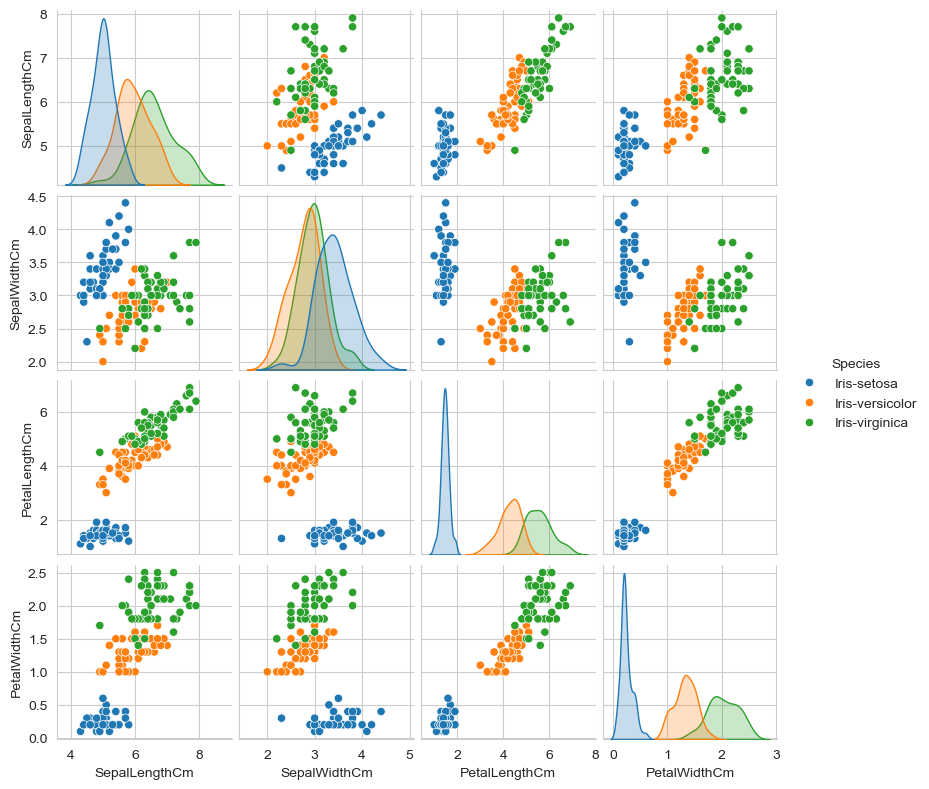

In [7]:
# Relación entre variables, coloreada por especie
sns.pairplot(iris.drop(columns=["Id"]), hue="Species", height=2)
plt.show()

## 3. Preparación de los datos

- Se elimina la columna `Id` porque no aporta información para la clasificación.
- `X` contiene las 4 variables predictoras (largo/ancho de sépalo y pétalo).
- `y` contiene la variable objetivo `Species`.

In [8]:
columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

X = iris[columns].values
y = iris["Species"].values

clases = sorted(iris["Species"].unique())
print("Variables de entrada:", columns)
print("Clases:", clases)

Variables de entrada: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Clases: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 4. División en entrenamiento (70%) y prueba (30%)

Se usa `train_test_split` con `stratify=y` para que ambos conjuntos mantengan la misma proporción de clases (50/50/50), y `random_state` fijo para que el resultado sea reproducible.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (105, 4)
Tamaño de prueba: (45, 4)


## 5. Escalado de variables

KNN y SVM son modelos sensibles a la escala de las variables (se basan en distancias), por lo que se estandarizan los datos (media 0, desviación 1). El escalador se **ajusta solo con el conjunto de entrenamiento** y luego se aplica a ambos conjuntos, para evitar fuga de información del conjunto de prueba.

El Árbol de Decisión no necesita escalado (no se basa en distancias), pero usar los mismos datos escalados no afecta su resultado.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Funciones auxiliares de evaluación

Para no repetir el mismo código tres veces, se define una función que:

1. Calcula la **matriz de confusión** y la grafica.
2. Calcula **TP, TN, FP, FN** por clase (enfoque uno-contra-todos) y con ellos la **exactitud**, **sensibilidad (recall)** y **especificidad**, igual que en las fórmulas de las diapositivas.
3. Imprime el `classification_report` de scikit-learn (precisión, recall, F1 por clase).

In [11]:
def metricas_por_clase(cm, clases):
    """Calcula TP, TN, FP, FN y métricas por clase a partir de la matriz de confusión
    usando el enfoque uno-contra-todos."""
    total = cm.sum()
    filas = []
    for i, clase in enumerate(clases):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP

        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        exactitud = (TP + TN) / total

        filas.append({
            "Clase": clase, "TP": TP, "TN": TN, "FP": FP, "FN": FN,
            "Exactitud": exactitud,
            "Recall (Sensibilidad)": recall,
            "Especificidad": especificidad,
            "Precisión": precision
        })
    return pd.DataFrame(filas)


def evaluar_modelo(nombre, y_test, y_pred, clases):
    """Imprime y grafica la matriz de confusión y las métricas de clasificación
    de un modelo, y devuelve un resumen (dict) con sus métricas macro."""
    print(f"\n========== {nombre} ==========\n")

    acc = accuracy_score(y_test, y_pred)
    print(f"Exactitud (Accuracy) global: {acc:.4f}\n")

    print("Reporte de clasificación (scikit-learn):")
    print(classification_report(y_test, y_pred, target_names=clases))

    cm = confusion_matrix(y_test, y_pred, labels=clases)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusión - {nombre}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    tabla = metricas_por_clase(cm, clases)
    print("Métricas por clase (TP, TN, FP, FN, recall, especificidad, precisión):")
    display(tabla)

    resumen = {
        "Modelo": nombre,
        "Accuracy": acc,
        "Precisión (macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "Especificidad (macro)": tabla["Especificidad"].mean(),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    }
    return resumen


resultados = []  # aquí se guarda el resumen de cada modelo

## 7. Modelo 1: KNN (K-Nearest Neighbors)

Clasifica cada punto según la clase mayoritaria entre sus *k* vecinos más cercanos. Se usa `k=5` (valor por defecto, razonable para este dataset).


========== KNN ==========

Exactitud (Accuracy) global: 0.9111

Reporte de clasificación (scikit-learn):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      1.00      0.88        15
 Iris-virginica       1.00      0.73      0.85        15

       accuracy                           0.91        45
      macro avg       0.93      0.91      0.91        45
   weighted avg       0.93      0.91      0.91        45



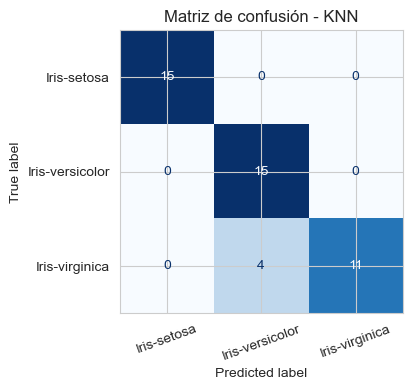

Métricas por clase (TP, TN, FP, FN, recall, especificidad, precisión):


,Clase,TP,TN,FP,FN,Exactitud,Recall (Sensibilidad),Especificidad,Precisión
0,Iris-setosa,15,30,0,0,1.0000,1.0000,1.0000,1.0000
1,Iris-versicolor,15,26,4,0,0.9111,1.0000,0.8667,0.7895
2,Iris-virginica,11,30,0,4,0.9111,0.7333,1.0000,1.0000


In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

resultados.append(evaluar_modelo("KNN", y_test, y_pred_knn, clases))

## 8. Modelo 2: SVM (Support Vector Machine)

Se usa un kernel **RBF** (no lineal), adecuado cuando las clases no son perfectamente separables con una línea recta.


========== SVM ==========

Exactitud (Accuracy) global: 0.9333

Reporte de clasificación (scikit-learn):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



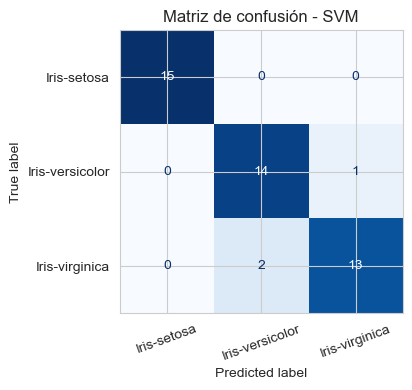

Métricas por clase (TP, TN, FP, FN, recall, especificidad, precisión):


,Clase,TP,TN,FP,FN,Exactitud,Recall (Sensibilidad),Especificidad,Precisión
0,Iris-setosa,15,30,0,0,1.0000,1.0000,1.0000,1.0000
1,Iris-versicolor,14,28,2,1,0.9333,0.9333,0.9333,0.8750
2,Iris-virginica,13,29,1,2,0.9333,0.8667,0.9667,0.9286


In [13]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

resultados.append(evaluar_modelo("SVM", y_test, y_pred_svm, clases))

## 9. Modelo 3: Árbol de Decisión

En este caso no es necesario limitar la profundidad (`max_depth`) porque Iris es un dataset pequeño y las clases están bien diferenciadas.


========== Árbol de Decisión ==========

Exactitud (Accuracy) global: 0.8889

Reporte de clasificación (scikit-learn):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.81      0.87      0.84        15
 Iris-virginica       0.86      0.80      0.83        15

       accuracy                           0.89        45
      macro avg       0.89      0.89      0.89        45
   weighted avg       0.89      0.89      0.89        45



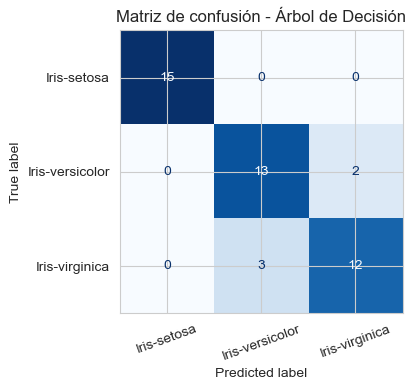

Métricas por clase (TP, TN, FP, FN, recall, especificidad, precisión):


,Clase,TP,TN,FP,FN,Exactitud,Recall (Sensibilidad),Especificidad,Precisión
0,Iris-setosa,15,30,0,0,1.0000,1.0000,1.0000,1.0000
1,Iris-versicolor,13,27,3,2,0.8889,0.8667,0.9000,0.8125
2,Iris-virginica,12,28,2,3,0.8889,0.8000,0.9333,0.8571


In [14]:
arbol = DecisionTreeClassifier(criterion="entropy", random_state=42)
arbol.fit(X_train_scaled, y_train)
y_pred_arbol = arbol.predict(X_test_scaled)

resultados.append(evaluar_modelo("Árbol de Decisión", y_test, y_pred_arbol, clases))

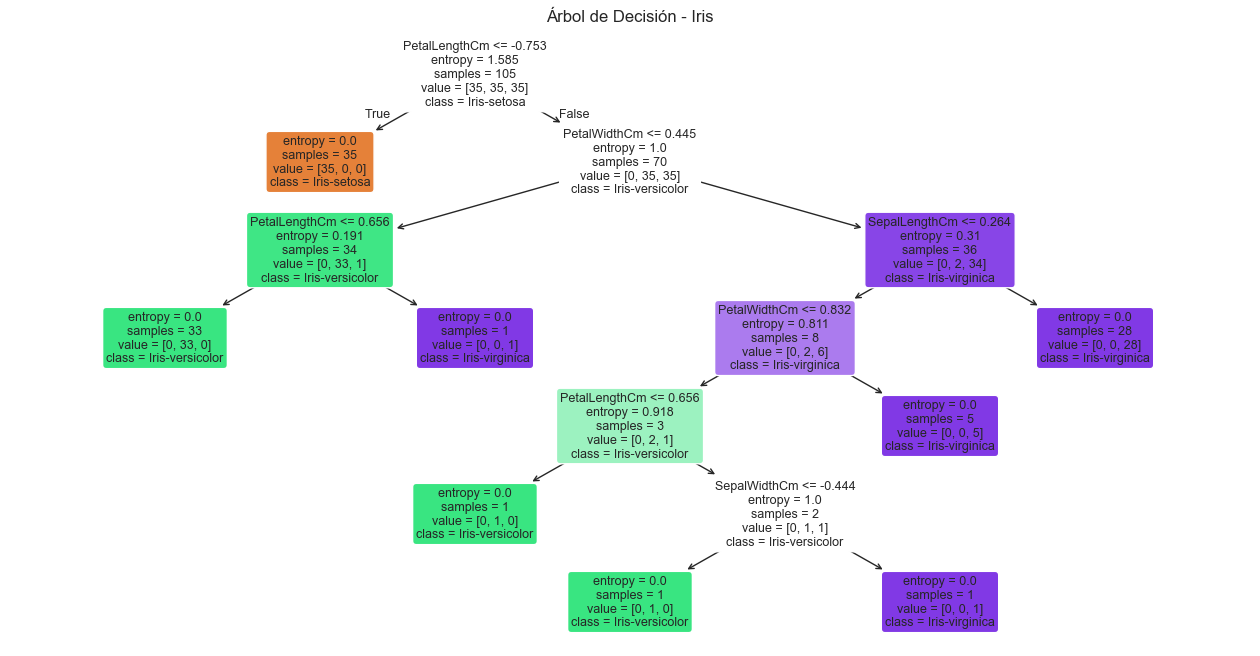

In [15]:
# Visualización del árbol entrenado
plt.figure(figsize=(16, 8))
plot_tree(arbol, feature_names=columns, class_names=arbol.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Árbol de Decisión - Iris")
plt.show()

## 10. Comparación final de los 3 modelos

In [16]:
tabla_resultados = pd.DataFrame(resultados).set_index("Modelo")
tabla_resultados

,Accuracy,Precisión (macro),Recall (macro),Especificidad (macro),F1 (macro)
Modelo,,,,,
KNN,0.9111,0.9298,0.9111,0.9556,0.9095
SVM,0.9333,0.9345,0.9333,0.9667,0.9333
Árbol de Decisión,0.8889,0.8899,0.8889,0.9444,0.8888


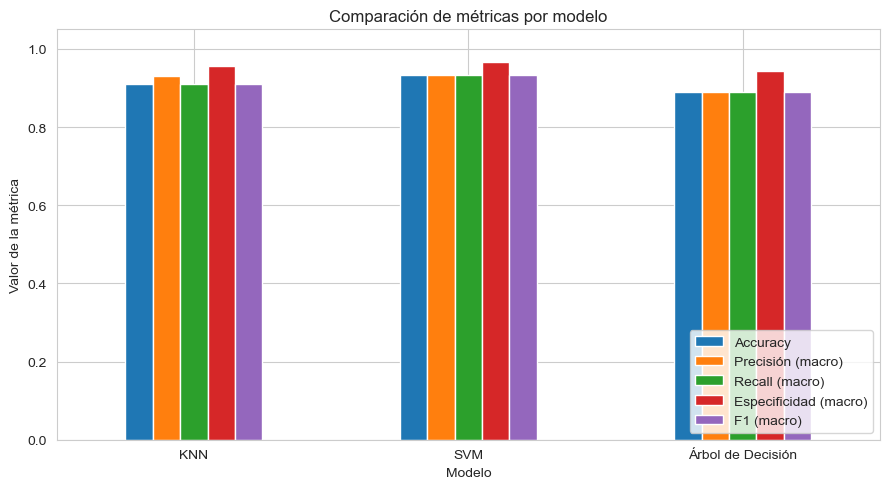

In [17]:
tabla_resultados.plot(kind="bar", figsize=(9, 5))
plt.title("Comparación de métricas por modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()